In [1]:
###---> Run in pyfesom2 env
import pyfesom2 as pf
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import so_ase as so
import scipy as sc
import cmocean.cm as cmo
from collections import defaultdict, deque, Counter
from tqdm import tqdm

/albedo/home/fheukamp/.conda/envs/pyfesom2/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/albedo/home/fheukamp/python_modules/pyfesom2/pyfesom2/ut.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/albedo/home/fheukamp/python_modules/pyfesom2/pyfesom2/climatology.py:14: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


osgeo is not installed, conversion to Geo formats like Geotiff (fesom2GeoFormat) will not work.


# Generate Quality Controlled Cavity File for FESOM2 (cavity_depth@node.out)
Change Log:    
- Initial Version: Finn Heukamp 10/2025

This script builds and optimizes the cavity_depth@node.out mesh file for FESOM2.

## 0. Settings/Parameters

In [28]:
###---> Input Paths
path_mesh_raw      = '/albedo/home/fheukamp/mesh/fmesh/mesh_jigsaw_test/mesh_RTopo2.0.4_30sec_SOCAV_v5/01_raw/' # elem2d.out, nod2d.out nodhn.out
path_mesh_smoothed = '/albedo/home/fheukamp/mesh/fmesh/mesh_jigsaw_test/mesh_RTopo2.0.4_30sec_SOCAV_v5/02_smoothed_bathymetry/' # depth_smooth.out

###---> Output Paths
destpath = '/albedo/home/fheukamp/mesh/fmesh/mesh_jigsaw_test/mesh_RTopo2.0.4_30sec_SOCAV_v5/03_cavity_depth/'

###---> Parameters
min_cavity_depth = -10

###---> Plotting
plot = False

## 1. Function Definitions

### 1.1 Mesh Reading Routines

In [4]:
def read_nodes(meshpath):
    with open(f'{meshpath}nod2d.out', 'r') as f:
        num_nodes = int(f.readline())
        nodes = []
        coast = []
        for _ in range(num_nodes):
            parts = f.readline().split()
            node_id = int(parts[0])
            lon = float(parts[1])
            lat = float(parts[2])
            coast_flag = float(parts[3])
            nodes.append((lon, lat))
            coast.append(coast_flag)
    return np.array(nodes), np.array(coast, dtype='bool')

def read_elements(meshpath):
    with open(f'{meshpath}elem2d.out', 'r') as f:
        num_elems = int(f.readline())
        elements = []
        for _ in range(num_elems):
            parts = f.readline().split()
            # Convert to 0-based indexing
            n1 = int(parts[0]) - 1
            n2 = int(parts[1]) - 1
            n3 = int(parts[2]) - 1
            elements.append((n1, n2, n3))
    return np.array(elements)

def read_depth(meshpath_1, meshpath_2):
    with open(f'{meshpath_2}nod2d.out', 'r') as f:
        num_nodes = int(f.readline())
    with open(f'{meshpath_1}depth_smooth.out', 'r') as f:
        depths = []
        for _ in range(num_nodes):
            parts = f.readline()
            d = float(parts)
            depths.append(d)
    return np.array(depths)

def read_cavity_depth(meshpath):
    with open(f'{meshpath}nod2d.out', 'r') as f:
        num_nodes = int(f.readline())
    with open(f'{meshpath}cavity_depth@node.out', 'r') as f:
        depths = []
        for _ in range(num_nodes):
            parts = f.readline()
            d = float(parts)
            depths.append(d)
    return np.array(depths)

### 1.2 Ice Base Interpolation Routine

In [5]:
def interpolate_cavity_depth(nodes, ds_icebase, method='nearest'):
    """
    Interpolates ice base topography onto mesh nodes and identifies cavity nodes.

    Parameters:
        nodes (array): node coordinates
        node_depths (list or array): ocean depth per node
        ds_icebase (xarray.Dataset): must contain 'ice_base_topography' on (lat, lon)
        method (str): interpolation method ('nearest', 'linear', or 'cubic')

    Returns:
        cavity_depth (np.array): negative values indicate ice base depth; 0 means no ice
        report (dict): basic summary
    """

    lons = nodes[:, 0]
    lats = nodes[:, 1]

    points = xr.Dataset(
        {
            "lon": (["points"], lons),
            "lat": (["points"], lats),
        }
    )

    # Interpolate ice base depth
    cavity_depth = ds_icebase["ice_base_topography"].interp(
        lon=points.lon, lat=points.lat, method=method
    ).values

    # Fill missing values
    cavity_depth[np.isnan(cavity_depth)] = 0.0
    
    report = {
        "total_nodes": len(cavity_depth),
        "cavity_nodes": int(np.sum(cavity_depth < 0)),
    }

    print("=== Interpolation Report ===")
    print(f"Total nodes: {report['total_nodes']}")
    print(f"Cavity nodes: {report['cavity_nodes']}")
    print(f'Minimum ice base depth: {max(cavity_depth[cavity_depth != 0])} m')
    print(f'Maximum ice base depth: {min(cavity_depth[cavity_depth != 0])} m')

    return cavity_depth

### 1.3 Cavity Optimization Routines

In [6]:
def find_open_ocean_clusters(elements, cavity_depth, verbose=True):
    """
    Identify connected clusters of open-ocean nodes (where cavity depth == 0).

    Parameters:
    -----------
    elements : list of tuple of int
        Triangular mesh elements as node index triples.
    filtered_cavity_depth : array-like
        Cavity depth values (0 for open ocean, < 0 for cavity).

    Returns:
    --------
    clusters : list of list of int
        List of clusters, each cluster is a list of node indices (open ocean only).
    """

    # Build neighbor graph from elements (only open-ocean nodes)
    neighbors = defaultdict(set)
    open_ocean_nodes = set(i for i, d in enumerate(cavity_depth) if d == 0)

    for tri in elements:
        for i in range(3):
            for j in range(3):
                if i != j:
                    ni = tri[i]
                    nj = tri[j]
                    if ni in open_ocean_nodes and nj in open_ocean_nodes:
                        neighbors[ni].add(nj)

    # Cluster open-ocean nodes using BFS
    visited = set()
    clusters = []

    for node in open_ocean_nodes:
        if node not in visited:
            cluster = []
            queue = deque([node])
            visited.add(node)

            while queue:
                current = queue.popleft()
                cluster.append(current)
                for neighbor in neighbors[current]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)

            clusters.append(cluster)

    clusters.sort(key=len, reverse=True)

    cluster_nodes = [item for c in clusters[1:] for item in c]

    if verbose:
        print("=== Open Ocean Clustering Report ===")
        print(f"Total # open-ocean clusters found: {len(clusters)}")
        print(f"Largest cluster size (global ocean): {len(clusters[0])}")
        print(f"Total nodes in open ocean clusters to fill: {len(cluster_nodes)}")

    return cluster_nodes

In [7]:
def fill_cavity_holes(cavity_depth, cluster_nodes, elements, verbose=True):
    """
    Iteratively fills missing (zero) cavity depths for given cluster_nodes
    using the mean depth of neighboring nodes connected via mesh elements.

    Parameters
    ----------
    cavity_depth : np.ndarray
        1D array of cavity depth values for each node.
    cluster_nodes : array-like
        Indices of nodes that belong to the cavity cluster.
    elements : np.ndarray
        2D array (n_elements x n_nodes_per_element) defining node connectivity.
    verbose : bool, optional
        If True, print progress messages.

    Returns
    -------
    cavity_depth_filled : np.ndarray
        Copy of `cavity_depth` with filled values.
    """

    
    cavity_depth_filled = cavity_depth

    # Mask of which cluster nodes still need filling
    mask = np.ones_like(cluster_nodes, dtype=bool)

    iteration = 0
    while np.any(mask):
        iteration += 1
    
        for i, cn in enumerate(cluster_nodes):
            if mask[i]:
                # Find all elements containing this node
                neighbor_mask = (elements == cn)
                elem_indices = np.where(neighbor_mask)[0]

                # Extract all node IDs connected to these elements
                neighbor_idx = np.unique(elements[elem_indices, :])

                # Remove the node itself
                neighbor_idx = neighbor_idx[neighbor_idx != cn]

                # Compute mean of nonzero neighboring cavity depths
                valid_neighbors = cavity_depth_filled[neighbor_idx]
                valid_neighbors = valid_neighbors[valid_neighbors != 0]

                if valid_neighbors.size > 0:
                    # Fill with mean of valid neighbor depths
                    cavity_depth_filled[cn] = valid_neighbors.mean()
                    mask[i] = False

        # Optional safety check to prevent infinite loops
        if iteration > 100:
            print("Warning: iteration limit reached, possible disconnected nodes.")
            break

    if verbose:
        print("\n=== Cavity Filling Report ===")
        print(f"Total filled nodes: {(~mask).sum()}/{len(mask)}")
        print(f"Total outer iterations: {iteration}")

    return cavity_depth_filled

In [8]:
def filter_small_cavity_clusters(elements, cavity_depth, N_min=100, verbose=True):
    """
    Filter out small connected clusters of ice-covered nodes.

    Parameters:
        elements (list of tuples): 0-based triangle node indices
        cavity_depth (list or np.array): cavity depth per node (< 0 means ice)
        N_min (int): minimum number of connected nodes to keep

    Returns:
        updated_cavity_depth (np.array): with small clusters removed
        report (dict): info about filtering
    """

    num_nodes = len(cavity_depth)
    ice_nodes = set(i for i, d in enumerate(cavity_depth) if d < 0)

    # Build connectivity graph for ice nodes only
    graph = defaultdict(set)
    for n1, n2, n3 in elements:
        for a, b in [(n1, n2), (n2, n3), (n3, n1)]:
            if a in ice_nodes and b in ice_nodes:
                graph[a].add(b)
                graph[b].add(a)

    # Find connected components
    visited = set()
    components = []

    for node in ice_nodes:
        if node in visited:
            continue
        q = deque([node])
        component = []
        while q:
            n = q.popleft()
            if n in visited:
                continue
            visited.add(n)
            component.append(n)
            q.extend(graph[n])
        components.append(component)

    # Filter small components
    removed_clusters = []
    removed_nodes = []
    filtered_cavity_depth = np.array(cavity_depth)  # ensure it's mutable
    for comp in components:
        if len(comp) < N_min:
            for node in comp:
                filtered_cavity_depth[node] = 0.0
                removed_nodes.append(node)
            removed_clusters.append(len(comp))

    report = {
        "total_clusters": len(components),
        "removed_clusters": len(removed_clusters),
        "removed_sizes": removed_clusters,
        "removed_nodes": len(removed_nodes)
    }

    if verbose:
        print("\n=== Cavity Filtering Report ===")
        print(f"Total clusters found: {report['total_clusters']}")
        print(f"Allowed cluster sizes: ({N_min}, n nodes]")
        print(f"Clusters removed: {report['removed_clusters']}")
        print(f"Nodes removed: {report['removed_nodes']}")
        print(f'Total (updated) number of cavity nodes: {sum(filtered_cavity_depth < 0)}')

    return filtered_cavity_depth, removed_nodes


In [9]:
def build_cavity_edges_and_endpoints(elements, cavity_depths, verbose=True):
    """
    Build all unique edges connecting cavity nodes (where cavity_depth < 0)
    and identify cavity nodes that appear only once (endpoints).

    Parameters
    ----------
    elements : (n_elements, 3) ndarray of int
        Triangular mesh connectivity, with node indices per element.
    cavity_depths : (n_nodes,) ndarray of float
        Depth values for each node. Cavity nodes are defined by depth < 0.
    verbose : bool, optional
        If True, print diagnostic information.

    Returns
    -------
    unique_edges : list of tuple(int, int)
        List of unique edges connecting two cavity nodes.
    nodes_appearing_once : list of int
        Nodes that appear in exactly one edge (endpoints of the cavity).
    node_counts : dict
        Dictionary mapping node index → number of connected edges.
    """

    # Identify cavity nodes
    mask_cavity = cavity_depths < 0

    # Build edge list
    edge_list = []
    for tri in elements:
        a, b, c = tri
        for e1, e2 in [(a, b), (b, c), (c, a)]:
            if mask_cavity[e1] and mask_cavity[e2]:
                edge_list.append(tuple(sorted((e1, e2))))  # always ordered

    # Remove duplicates efficiently
    unique_edges = list(set(edge_list))

    # Flatten all nodes appearing in edges
    nodes_in_edges = [i for edge in unique_edges for i in edge]

    # Count how many times each node appears
    node_counts = Counter(nodes_in_edges)

    # Nodes that appear only once (endpoints)
    nodes_appearing_once = [node for node, count in node_counts.items() if count == 1]

    if verbose:
        print("\n=== Cavity Remove Loose Ends Report ===")
        print(f"Total unique cavity-only edges: {len(unique_edges)}")
        print(f"Nodes to convert to ocean (connected by exactly one edge): {len(nodes_appearing_once)}")
       
    return nodes_appearing_once

In [10]:
def close_ocean_channels_in_cavity(elements, cavity_depth, verbose=True):
    """
    Fills small 'loose end' ocean channels within cavities by converting
    isolated ocean nodes (connected to cavity by exactly one edge)
    into cavity nodes.

    Parameters
    ----------
    elements : (n_elements, 3) ndarray of int
        Triangular mesh connectivity.
    cavity_depth : (n_nodes,) ndarray of float
        Depth values for each node (<0 = cavity, >=0 = ocean).
    verbose : bool
        If True, print progress information.

    Returns
    -------
    cavity_depth : ndarray
        Updated cavity_depth array (in-place modification).
    corrected_node_count : int
        Number of ocean nodes converted to cavity.
    """

    if verbose:
        print("\n=== Ocean Remove Loose Ends Report ===")

    mask_cavity = cavity_depth < 0
    n_nodes = len(cavity_depth)

    # --- Build all edges (vectorized) ---
    edges = np.vstack([
        elements[:, [0, 1]],
        elements[:, [1, 2]],
        elements[:, [2, 0]]
    ])
    edges = np.sort(edges, axis=1)  # canonical order for deduplication
    edges = np.unique(edges, axis=0)

    # --- Identify edges connecting cavity↔ocean ---
    mask_edge_cavity = mask_cavity[edges[:, 0]]
    mask_edge_ocean  = mask_cavity[edges[:, 1]]
    # XOR finds True when exactly one is cavity
    edge_cavity_ocean = np.logical_xor(mask_edge_cavity, mask_edge_ocean)
    edges_co = edges[edge_cavity_ocean]

    # --- Find unique nodes appearing in these edges ---
    nodes_in_edges = np.unique(edges_co)

    if verbose:
        print(f"Number of nodes in cavity-ocean edges: {len(nodes_in_edges)}")

    # --- Precompute neighbors for all nodes (faster than searching) ---
    # Build adjacency list (set of neighbor indices for each node)
    neighbors = [[] for _ in range(n_nodes)]
    for e0, e1, e2 in elements:
        neighbors[e0].extend((e1, e2))
        neighbors[e1].extend((e0, e2))
        neighbors[e2].extend((e0, e1))

    # Convert to unique sorted neighbor arrays (optional for speed)
    neighbors = [np.unique(nbrs) for nbrs in neighbors]

    # --- Process nodes ---
    corrected_node_count = 0
    for node in nodes_in_edges:
        if not mask_cavity[node]:  # ocean node only
            nbrs = neighbors[node]
            mask_nbrs_cavity = mask_cavity[nbrs]
            n_ocean_neighbors = np.count_nonzero(~mask_nbrs_cavity)

            if n_ocean_neighbors == 1 and np.any(mask_nbrs_cavity):
                cavity_depth[node] = np.mean(cavity_depth[nbrs[mask_nbrs_cavity]])
                mask_cavity[node] = True  # update mask
                corrected_node_count += 1

    if verbose:
        print(f"Loose-end ocean nodes converted to cavity: {corrected_node_count}")

    return cavity_depth, corrected_node_count

In [11]:
def plot_modifications(q_lat, q_lon, backup, iter_count):
    fig, ax = plt.subplots(1,1, figsize=(30,30), subplot_kw=dict(projection=ccrs.SouthPolarStereo()))

    for axis in [ax]:
        axis.set_facecolor('grey')
        so.create_map(axis, extent=[-180,180,-90,-60], land=False, coastline=True)
    
    # Open Ocean
    mask = (q_lat < -60) & (backup[-1] == 0)
    cb = ax.scatter(q_lon[mask], q_lat[mask], s=.01, color='b', transform=ccrs.PlateCarree())
    
    # Cavity
    mask = (backup[-1] != 0)
    cb = ax.scatter(q_lon[mask], q_lat[mask], s=.01, color='w', transform=ccrs.PlateCarree())
    
    # Cavity to Open Ocean
    mask = backup[-1] != backup[0]
    cb = ax.scatter(q_lon[mask], q_lat[mask], s=.1, color='r', transform=ccrs.PlateCarree())
    
    plt.savefig(f'Fig_{iter_count}.pdf', bbox_inches='tight')

## 2. Main Program

### 2.1 Load and Manipulate RTopo2.0.4 Ice Base
Loads and manipulates RTopo2.0.4 for further processing in the cavity generation.

In [12]:
###---> Load RTopo2.0.4 Ice Base
ds_icebase = xr.open_dataset('/albedo/home/fheukamp/PostDoc2/mesh_generation/RTopo-2.0.4/RTopo-2.0.4_30sec_ice_base_topography.nc')

# Step 1: Rename dimensions
ds_icebase = ds_icebase.swap_dims({'londim': 'lon', 'latdim': 'lat'})

# Step 2: Rename coordinates (if necessary)
ds_icebase = ds_icebase.rename_vars({'lon': 'lon', 'lat': 'lat'})

# Step 3: Ensure coordinates are correctly assigned to those dimensions
ds_icebase = ds_icebase.assign_coords(lon=ds_icebase.lon, lat=ds_icebase.lat)

# Step 4: Transpose Dimensions
ds_icebase = ds_icebase.transpose('lon', 'lat')

# Step 5: Cut to south of 60S
ds_icebase = ds_icebase.sel(lat=slice(-90,-60))

# Step 6 (Optional): Remove Iceberg c23 in Weddell Sea
print(f'Remove Iceberg c23 in Weddell Sea...')
d = ds_icebase.ice_base_topography.values
d[16400:16900, 1600:1800] = np.zeros_like(d[16400:16900, 1600:1800])
ds_icebase['ice_base_topography'] = (('lon','lat'), d)

# Step 7 (Optional): Remove positive elevation
print(f'Set positive elevation to 0...')
ds_icebase['ice_base_topography'] = (('lon','lat'), np.where(ds_icebase.ice_base_topography.values > 0, 0, ds_icebase.ice_base_topography.values))#ds_icebase.ice_base_topography.where(ds_icebase.ice_base_topography > 0, 0)


Remove Iceberg c23 in Weddell Sea...
Set positive elevation to 0...


### 2.2 Load Raw Mesh Files

In [13]:
nodes, coast_flag = read_nodes(path_mesh_raw)
elements = read_elements(path_mesh_raw)
node_depths = read_depth(path_mesh_smoothed, path_mesh_raw)

### 2.3 Interpolate RTopo2.0.4 Ice Base to FESOM2 mesh

In [14]:
cavity_depth = interpolate_cavity_depth(
    nodes,
    ds_icebase.copy(),
    method="nearest",
)

=== Interpolation Report ===
Total nodes: 3222974
Cavity nodes: 80009
Minimum ice base depth: -0.03972122073173523 m
Maximum ice base depth: -2273.37060546875 m


### 2.3 Optimization
The optimization improves the quality of the cavities in the final mesh by:  
i) Identifying holes in the cavities (open ocean nodes entirely surrounded by cavity nodes),
ii) Filling the identified holes in the cavities,
iii) Filtering cavity clusters below a certain threshold (minimum number of connected cavity nodes, e.g. 15),
iv) Removing narrow channels of ocean in the cavities/cavity in the ocean (nodes which can only be reached via a single edge)  
The main program runs until all requirements are fulfilled, e.g. until none of the above 4 optimization processes modifies a node.  
After each iteration of the optimization, a figure with all adjustments is printed.

In [15]:
exit_flag_1 = True
exit_flag_2 = True
exit_flag_3 = True
exit_flag_4 = True

iter_count = 0
backup = []
backup.append(cavity_depth)
lons = nodes[:, 0]
lats = nodes[:, 1]

cavity_depth_mod = cavity_depth.copy()

while (exit_flag_1 or exit_flag_2 or exit_flag_3 or exit_flag_4):
    iter_count += 1
    print(f"\n=================== ITERATION #{iter_count} ===================\n")
    
    # Find Open Ocean Clusters Trapped in Cavity
    nodes_2_fill = find_open_ocean_clusters(elements, cavity_depth_mod)
    
    if len(nodes_2_fill) == 0:
        exit_flag_1 = False
    else:
        exit_flag_1 = True
        # Fill Open Ocean Clusters Trapped in Cavity
        cavity_depth_mod = fill_cavity_holes(cavity_depth_mod, nodes_2_fill, elements, verbose=True)
    
    
    # Filter Small Cavity Clusters
    cavity_depth_mod, nodes_filtered = filter_small_cavity_clusters(elements, cavity_depth_mod, N_min=15, verbose=True)
    
    if len(nodes_filtered) == 0:
        exit_flag_2 = False
    else:
        exit_flag_2 = True
    
    # Filter Single Ends (Cavity)
    internal_exit_flag_1 = True
    iter_count_2 = 0
    while internal_exit_flag_1: #
        iter_count_2 += 1
        nodes_2_convert = build_cavity_edges_and_endpoints(elements, cavity_depth_mod, verbose=True)
        print(f"Inner Iteration - Remove Loose Ends Cavity: {iter_count_2}")
        
        if len(nodes_2_convert) == 0:
            if iter_count_2 == 1:
                exit_flag_3 = False
                internal_exit_flag_1 = False
            else:
                exit_flag_3 = True
                internal_exit_flag_1 = False
        else:
            exit_flag_3 = True
            cavity_depth_mod[nodes_2_convert] = 0

    # Filter Single Ocean Ends in Cavity
    internal_exit_flag_2 = True
    iter_count_3 = 0
    while internal_exit_flag_2:
        iter_count_3 += 1
        cavity_depth_mod, corrected_node_count = close_ocean_channels_in_cavity(elements, cavity_depth_mod)
        print(f"Inner Iteration - Remove Loose Ends Ocean: {iter_count_3}")
        if corrected_node_count == 0:
            if iter_count_3 == 1:
                internal_exit_flag_2 = False
                exit_flag_4 = False
            else:
                internal_exit_flag_2 = False
                exit_flag_4 = True
        
        
    print(f'\n===> Open Ocean Clusters Requirement Converged: {not exit_flag_1}')
    print(f'===> Cavity Clusters Filter Requirement Converged: {not exit_flag_2}')
    print(f'===> Cavity Loose Ends Requirement Converged: {not exit_flag_3}')
    print(f'===> Ocean Loose Ends Requirement Converged: {not exit_flag_4}')

    backup.append(cavity_depth_mod)

    if plot:
        plot_modifications(lats, lons, backup, iter_count)
    
    if iter_count == 15:
        print("Maximum iterations reached!")
        break

print("All requirements fulfilled :-) !")


=================== ITERATION #1 ===================

=== Open Ocean Clustering Report ===
Total # open-ocean clusters found: 288
Largest cluster size (global ocean): 3142179
Total nodes in open ocean clusters to fill: 786

=== Cavity Filling Report ===
Total filled nodes: 786/786
Total outer iterations: 2

=== Cavity Filtering Report ===
Total clusters found: 333
Allowed cluster sizes: (15, n nodes]
Clusters removed: 254
Nodes removed: 879
Total (updated) number of cavity nodes: 79916

=== Cavity Remove Loose Ends Report ===
Total unique cavity-only edges: 227590
Nodes to convert to ocean (connected by exactly one edge): 109
Inner Iteration - Remove Loose Ends Cavity: 1

=== Cavity Remove Loose Ends Report ===
Total unique cavity-only edges: 227481
Nodes to convert to ocean (connected by exactly one edge): 46
Inner Iteration - Remove Loose Ends Cavity: 2

=== Cavity Remove Loose Ends Report ===
Total unique cavity-only edges: 227435
Nodes to convert to ocean (connected by exactly one

### 2.4 Plot Final Cavity Mask

In [16]:
# Masks
mask_cavity = (cavity_depth_mod < 0)
mask_ocean = (cavity_depth_mod == 0)
mask_cavity2ocean = (cavity_depth < 0) & (cavity_depth_mod == 0)
mask_ocean2cavity = (cavity_depth == 0) & (cavity_depth_mod < 0)

/albedo/home/fheukamp/.conda/envs/pyfesom2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


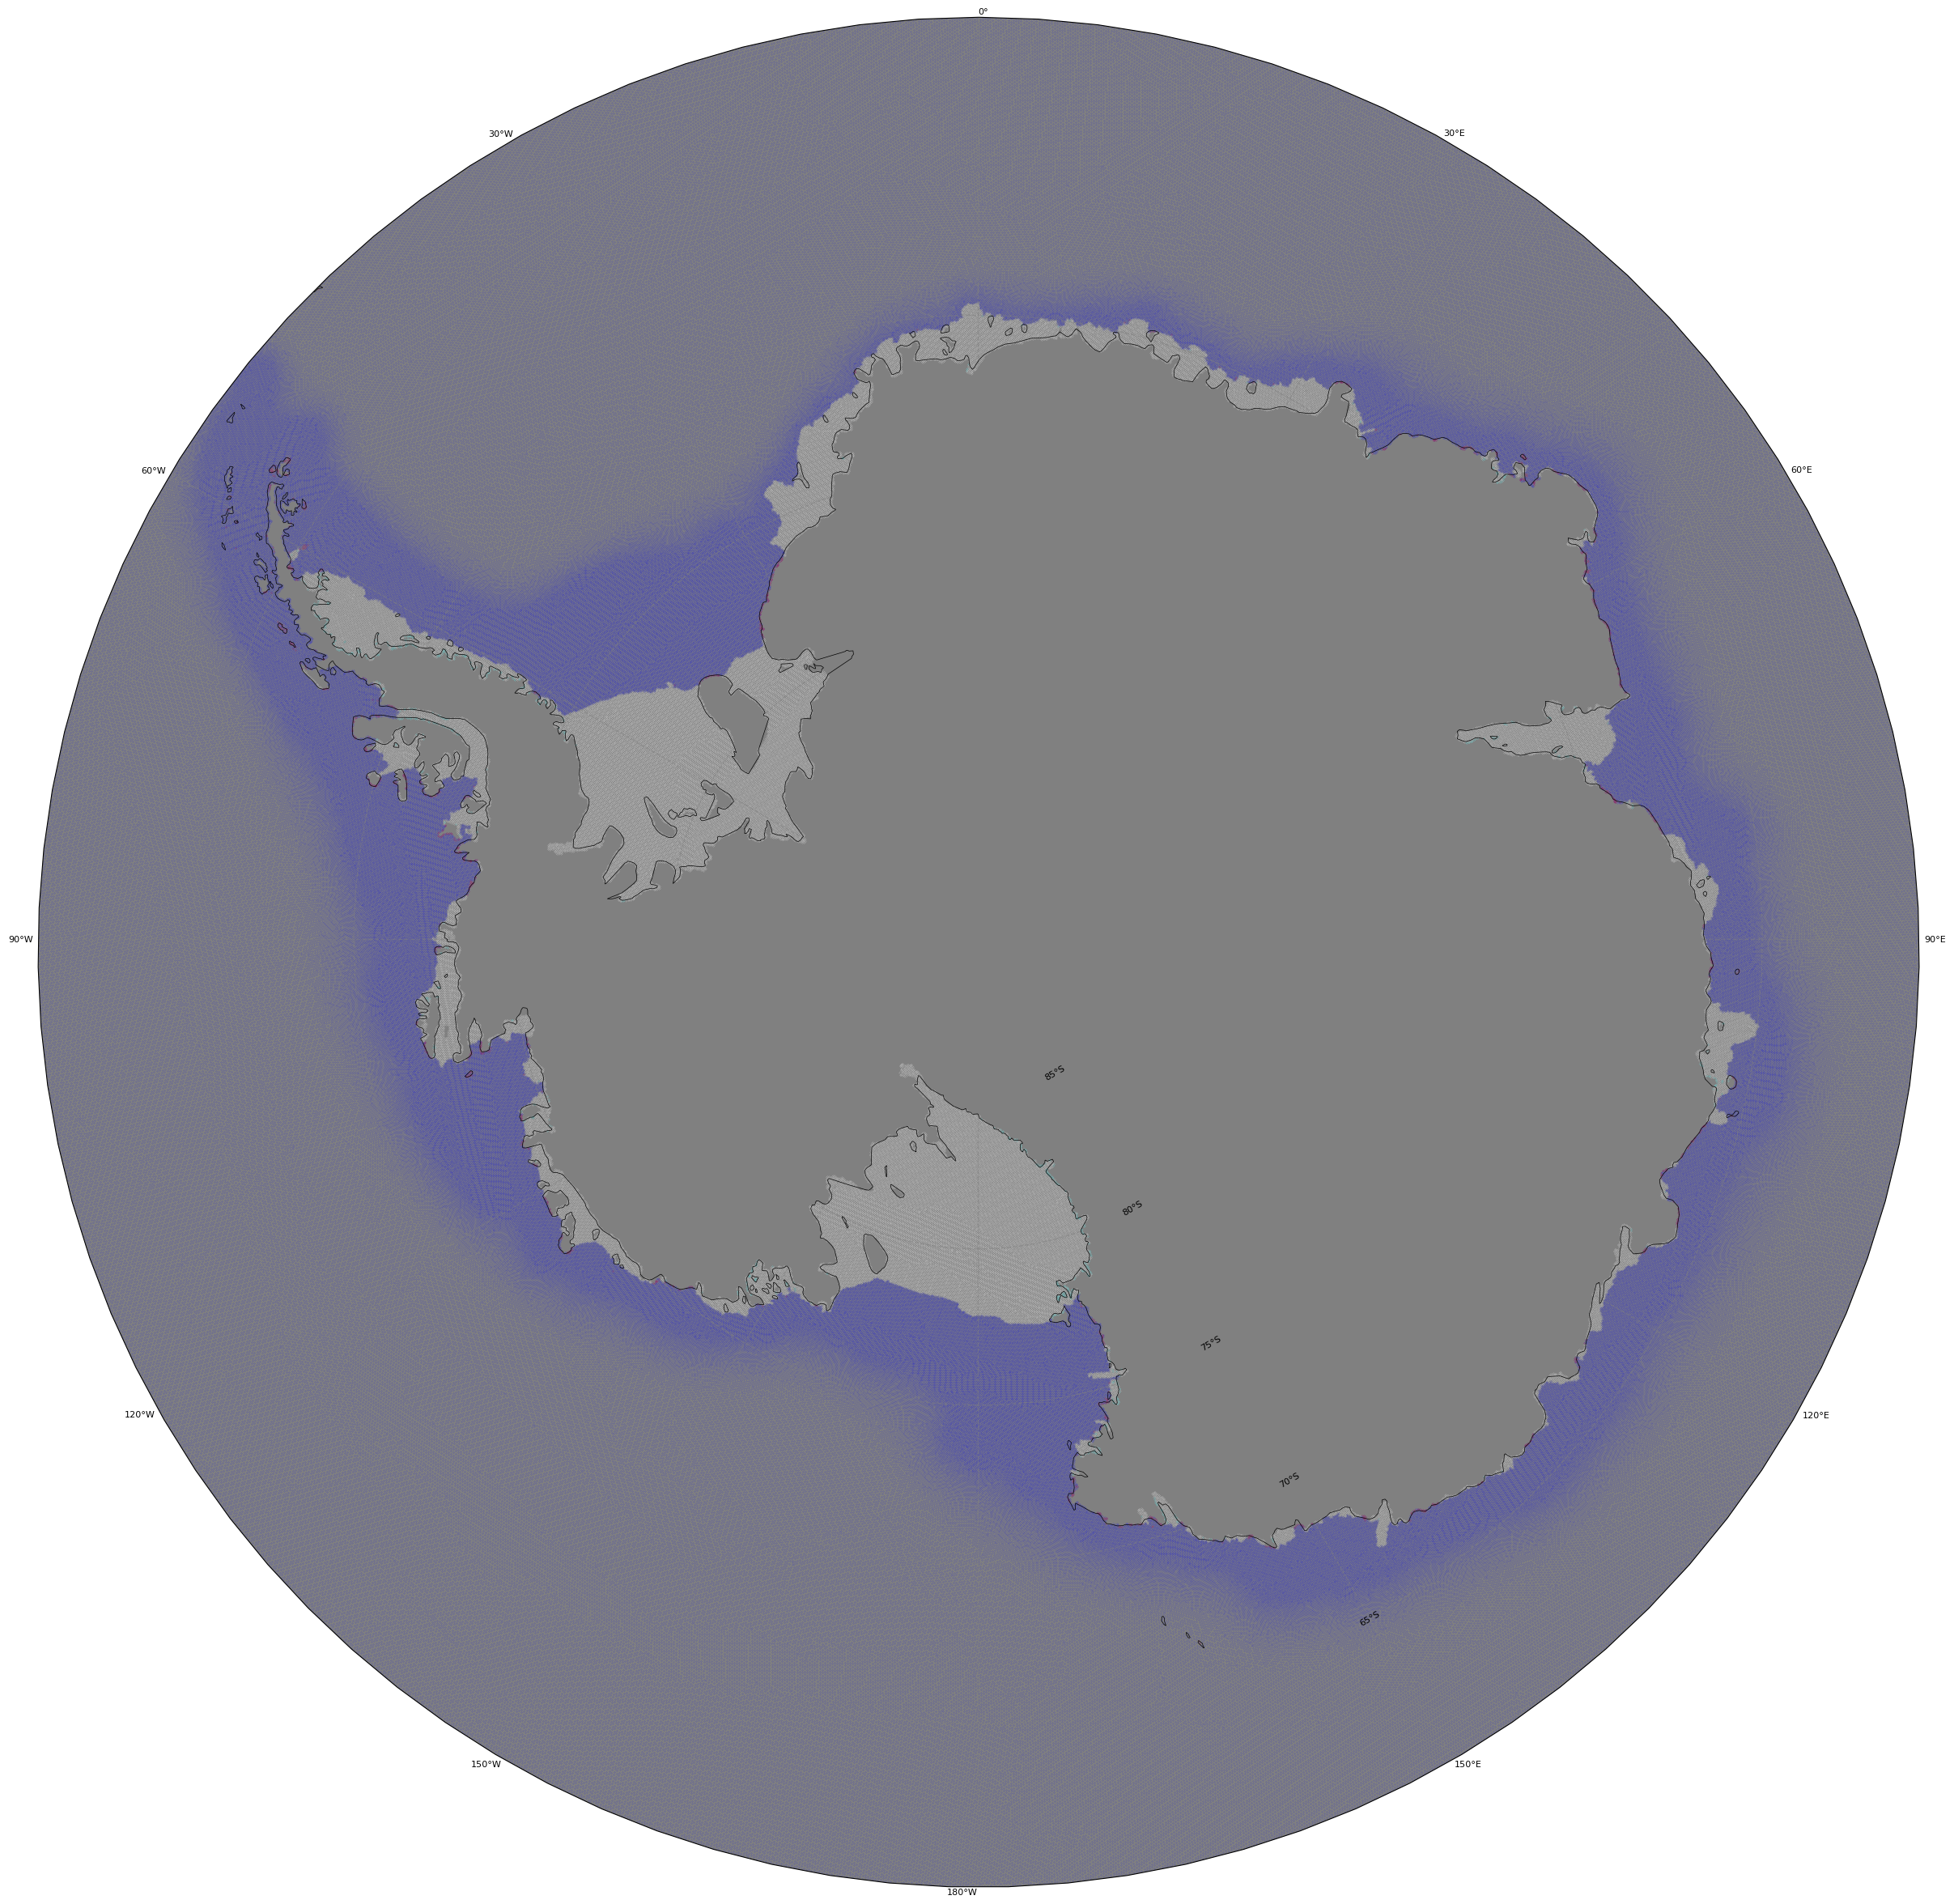

In [19]:
if plot:
    fig, ax = plt.subplots(1,1, figsize=(30,30), subplot_kw=dict(projection=ccrs.SouthPolarStereo()))
    
    for axis in [ax]:
        axis.set_facecolor('grey')
        so.create_map(axis, extent=[-180,180,-90,-60], land=False, coastline=True)
    
    # Open Ocean
    mask = mask_ocean
    cb = ax.scatter(lons[mask], lats[mask], s=.01, color='b', transform=ccrs.PlateCarree())
    
    # Cavity
    mask = mask_cavity
    cb = ax.scatter(lons[mask], lats[mask], s=.01, color='w', transform=ccrs.PlateCarree())
    
    # Ocean to Cavity
    mask = mask_ocean2cavity
    cb = ax.scatter(lons[mask], lats[mask], s=.01, color='c', transform=ccrs.PlateCarree())
    
    # Cavity to Ocean
    mask = mask_cavity2ocean
    cb = ax.scatter(lons[mask], lats[mask], s=.01, color='r', transform=ccrs.PlateCarree())
    
    plt.savefig(f'Fig_final.pdf', bbox_inches='tight')

### 2.5 Adjust Seafloor

In [23]:
print(f"The minimum cavity depth is: {max(cavity_depth_mod[cavity_depth_mod < 0])}m")
print(f"The maximum cavity depth is: {min(cavity_depth_mod[cavity_depth_mod < 0])}m")

The minimum cavity depth is: -0.03972122073173523m
The maximum cavity depth is: -2273.37060546875m


In [24]:
# Enforce minimum cavity depth
mask_shallow_cavity = (cavity_depth_mod > min_cavity_depth) & (cavity_depth_mod != 0)
cavity_depth_mod[mask_shallow_cavity] = min_cavity_depth

In [25]:
print(f"The minimum adjusted cavity depth is: {max(cavity_depth_mod[cavity_depth_mod < 0])}m")
print(f"The maximum adjusted cavity depth is: {min(cavity_depth_mod[cavity_depth_mod < 0])}m")

The minimum adjusted cavity depth is: -10.0m
The maximum adjusted cavity depth is: -2273.37060546875m


In [26]:
# Deepen bedrock where ice base shallower than bathymetry (50m difference is enforced)
#mask_depth_mismatch = (cavity_depth_mod < node_depths)
#node_depths_mod = np.where(mask_depth_mismatch, cavity_depth_mod - 50, node_depths)

### 2.6 Save Mesh Files

In [29]:
destpath = "/albedo/home/fheukamp/mesh/fmesh/mesh_jigsaw_test/mesh_RTopo2.0.4_30sec_SOCAV_v5/03_cavity_depth/"

In [30]:
# cavity_depth@node.out
with open(f'{destpath}cavity_depth.out', 'w') as f:
    for l in cavity_depth_mod:
        f.write(f"{int(l)}.0\n")

In [32]:
# aux3d.out

node_levels = [0.0,-5.0,-10.0,-20.0,-30.0,-40.0,-50.0,-60.0,-70.0,-80.0,-90.0,-100.0,
              -115.0,-130.0,-145.0,-160.0,-180.0,-200.0,-225.0,-250.0,-275.0,-300.0,
              -325.0,-350.0,-375.0,-400.0,-450.0,-500.0,-550.0,-600.0,-650.0,-700.0,
              -800.0,-900.0,-1040.0,-1180.0,-1330.0,-1500.0,-1700.0,-1920.0,-2150.0,
              -2400.0,-2650.0,-2900.0,-3150.0,-3400.0,-3650.0,-3900.0,-4150.0,-4400.0,
              -4650.0,-4900.0,-5150.0,-5400.0,-5650.0,-6000.0,-6250.0]

with open(f'{destpath}aux3d.out', 'w') as f:
    f.write(f"{int(len(node_levels))}\n")
    for l in node_levels:
        f.write(f"{int(l)}.0\n")
    for l in node_depths:
        f.write(f"{int(l)}.0\n")

In [ ]:
# depth.out
with open(f'{destpath}depth.out', 'w') as f:
    for l in node_depths_mod:
        f.write(f"{int(l)}.0\n")

Next step: Run correct_cavity_SO.m in ../matlab/

## 3. Figures

### 3.1 Global Cavity Mask

In [ ]:
if plot:
    fig, ax = plt.subplots(1,1, figsize=(30,15), subplot_kw=dict(projection=ccrs.PlateCarree()))
    
    for axis in [ax]:
        axis.set_facecolor('grey')
        so.create_map(axis, extent=[-180,180,-90,90], land=False, coastline=True, circular=False)
    
    # Open Ocean
    mask = (cavity_depth_mod == 0)
    cb = ax.scatter(lons[mask], lats[mask], s=.01, color='b', transform=ccrs.PlateCarree())
    
    # Open Ocean
    mask = (cavity_depth_mod < 0)
    cb = ax.scatter(lons[mask], lats[mask], s=.01, color='r', transform=ccrs.PlateCarree())

### 3.2 Global Bathymetry

In [ ]:
if plot:
    fig, ax = plt.subplots(1,1, figsize=(30,15), subplot_kw=dict(projection=ccrs.PlateCarree()))
    
    for axis in [ax]:
        axis.set_facecolor('grey')
        so.create_map(axis, extent=[-180,180,-90,90], land=False, coastline=True, circular=False)
    
    cb = ax.scatter(lons, lats, s=.01, c=node_depths_mod, cmap=cmo.deep_r, vmin=-6250, vmax=0, transform=ccrs.PlateCarree())

## 4. Debugging

### Vicinity of Blowup

In [ ]:
meshpath = '/albedo/home/fheukamp/mesh/fmesh/mesh_jigsaw_test/mesh_RTopo2.0.4_30sec_SOCAV_v4/05_final/corrected/'

In [ ]:
def read_elvls(meshpath, which='seafloor'):
    with open(f'{meshpath}elem2d.out', 'r') as f:
        num_elem = int(f.readline())
    if which == 'seafloor':
        filename = 'elvls.out'
    elif which == 'cavity':
        filename = 'cavity_elvls.out'
    with open(f'{meshpath}{filename}', 'r') as f:
        elvls = []
        for _ in range(num_elem):
            parts = f.readline()
            elvls.append(int(parts))
    return np.array(elvls)

In [ ]:
elvls_cav = read_elvls(meshpath, which='cavity')
elvls_bot = read_elvls(meshpath, which='seafloor')
cavity_depth = read_cavity_depth(meshpath)

In [ ]:
lons = nodes[:, 0]
lats = nodes[:, 1]

In [ ]:
# Node that failed
node_id  = 291132-1 # subtrac 1 for python indexing

print(str(lons[node_id]) + ' E')
print(str(lats[node_id]) + ' N')

In [ ]:
# Copied from blowup report
glon, glat   =   -61.3728000000000, -70.4436000000000

In [ ]:
# Find triangles connecting to the node
tri_mask = np.sum(elements == node_id, axis=1) == 1

In [ ]:
if plotting:
fig, ax = plt.subplots(1,1, figsize=(30,30), subplot_kw=dict(projection=ccrs.SouthPolarStereo()))

for axis in [ax]:
    axis.set_facecolor('grey')
    so.create_map(axis, extent=[-180,180,-90,-60], land=False, coastline=True)

# Cavity
mask = (cavity_depth < 0)
cb = ax.scatter(lons[mask], lats[mask], s=.01, color='w', transform=ccrs.PlateCarree())

ax.scatter(glon, glat, s=.01, color='r', transform=ccrs.PlateCarree())
ax.scatter(lons[elements[tri_mask]].mean(axis=1), lats[elements[tri_mask]].mean(axis=1), s=.001, color='b', marker='x', transform=ccrs.PlateCarree())

plt.savefig(f'Fig_Debug.pdf', bbox_inches='tight')

In [ ]:
mesh = pf.load_mesh(meshpath)

#### First/Last Active Layer of Elements

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(20,15))#, subplot_kw=dict(projection=ccrs.PlateCarree()))


d=1
box=[glon-d, glon+d, glat-d, glat+d]
ax.set_xlim((glon-d, glon+d))
ax.set_ylim((glat-d, glat+d))

data_to_plot_1 = elvls_cav
elem_no_nan, no_nan_triangles = pf.cut_region(mesh, box)
no_cyclic_elem2 = pf.get_no_cyclic(mesh, elem_no_nan)

data_to_plot_1 = data_to_plot_1[no_nan_triangles][no_cyclic_elem2]
#data_to_plot_1[data_to_plot_1 == 0] = np.nan
elem_to_plot = elem_no_nan[no_cyclic_elem2]

image = ax.tripcolor(
                mesh.x2,
                mesh.y2,
                elem_to_plot,
                data_to_plot_1, cmap=cmo.deep, vmin=1, vmax=57, edgecolor='k')
#,
#                transform=ccrs.PlateCarree())


plt.colorbar(image)

ax.scatter(glon, glat, s=10, color='r')
#ax.scatter(lons[elements[tri_mask]].mean(axis=1), lats[elements[tri_mask]].mean(axis=1), s=10, color='b', marker='x')

elons = lons[elem_to_plot].mean(axis=1)
elats = lats[elem_to_plot].mean(axis=1)
clev_1 = [str(d) for d in data_to_plot_1]

for x, y, flev in zip(elons, elats, clev_1):
    ax.text(x,y,flev, fontsize=6, ha='center', va='center')

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(20,15))#, subplot_kw=dict(projection=ccrs.PlateCarree()))


d=1
box=[glon-d, glon+d, glat-d, glat+d]
ax.set_xlim((glon-d, glon+d))
ax.set_ylim((glat-d, glat+d))

data_to_plot_2 = elvls_bot
elem_no_nan, no_nan_triangles = pf.cut_region(mesh, box)
no_cyclic_elem2 = pf.get_no_cyclic(mesh, elem_no_nan)

data_to_plot_2 = data_to_plot_2[no_nan_triangles][no_cyclic_elem2]
#data_to_plot_2[data_to_plot_2 == 0] = np.nan
elem_to_plot = elem_no_nan[no_cyclic_elem2]

image = ax.tripcolor(
                mesh.x2,
                mesh.y2,
                elem_to_plot,
                data_to_plot_2, cmap=cmo.deep, vmin=1, vmax=57, edgecolor='k')
#,
#                transform=ccrs.PlateCarree())


plt.colorbar(image)

ax.scatter(glon, glat, s=10, color='r')
#ax.scatter(lons[elements[tri_mask]].mean(axis=1), lats[elements[tri_mask]].mean(axis=1), s=10, color='b', marker='x')

elons = lons[elem_to_plot].mean(axis=1)
elats = lats[elem_to_plot].mean(axis=1)
clev_2 = [str(d) for d in data_to_plot_2]

for x, y, nlev in zip(elons, elats, clev_2):
    ax.text(x,y,flev, fontsize=6, ha='center', va='center')

#### Ovelapping Layers at Edges

In [ ]:
# Identify cavity elements
mask_cavity = data_to_plot_1 > 1

# Build edge list
edge_list = []
for tri in elem_to_plot:
    a, b, c = tri
    for e1, e2 in [(a, b), (b, c), (c, a)]:
        edge_list.append(tuple(sorted((e1, e2))))  # always ordered

edge_list
# Remove duplicates efficiently
unique_edges = list(set(edge_list))

In [ ]:
n_overlapping_layers_at_edges = []
layers = np.arange(1,58, 1)

for edge in unique_edges:
    i, j = edge
    mask = ((elem_to_plot == i) | (elem_to_plot == j))
    mask_share_edge = (mask.sum(axis=1) == 2)
    if mask_share_edge.sum() == 1: # coastal edge
        n_overlapping_layers_at_edges.append(0)
    elif mask_share_edge.sum() == 2: # ocean edge
        cav_depth_a = data_to_plot_1[mask_share_edge][0]
        cav_depth_b = data_to_plot_1[mask_share_edge][1]
        if cav_depth_a > cav_depth_b:
            first_common_layer = cav_depth_a
        else: first_common_layer = cav_depth_b
    
        bot_depth_a = data_to_plot_2[mask_share_edge][0]
        bot_depth_b = data_to_plot_2[mask_share_edge][1]
        if bot_depth_a < bot_depth_b:
            last_common_layer = bot_depth_a
        else: last_common_layer = bot_depth_b
    
        diff = last_common_layer - first_common_layer + 1
        n_overlapping_layers_at_edges.append(diff)




In [ ]:
edge_lons = lons[unique_edges]
edge_lats = lats[unique_edges]

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(20,15))#, subplot_kw=dict(projection=ccrs.PlateCarree()))

ax.set_facecolor('lightgrey')

d=1
box=[glon-d, glon+d, glat-d, glat+d]
ax.set_xlim((glon-d, glon+d))
ax.set_ylim((glat-d, glat+d))

###---> Triangels
z = (np.array(data_to_plot_1) == 1)
image = ax.tripcolor(
                mesh.x2,
                mesh.y2,
                elem_to_plot,
                z, cmap='Blues', vmin=0, vmax=2, edgecolor='k')
#,
#                transform=ccrs.PlateCarree())


#plt.colorbar(image, label='# active layers', shrink=.5, aspect=20)

###---> Cavity Nodes/Blowup Node
mask = (cavity_depth < 0)
ax.scatter(lons[mask], lats[mask], s=20, color='w', edgecolor='k', label = 'cavity nodes (cavity_depth@node.out)')
ax.scatter(glon, glat, s=20, color='r', marker='x', label = 'blow up node (salt = nan)')
#ax.scatter(lons[elements[tri_mask]].mean(axis=1), lats[elements[tri_mask]].mean(axis=1), s=10, color='b', marker='x')

###---> Text Triangle Center
z = data_to_plot_2 - data_to_plot_1 + 1

elons = lons[elem_to_plot].mean(axis=1)
elats = lats[elem_to_plot].mean(axis=1)
clev_3 = [str(d) for d in z]

number = [str(a) + ',' + str(b) + ',' + str(c) for a, b, c in zip(clev_1, clev_2, clev_3)]

for x, y, flev in zip(elons, elats, number):
    ax.text(x-.03, y, flev, fontsize=6, ha='left', va='center')


###---> Overlapping Layers at Edges
edge_lons = lons[unique_edges].mean(axis=1)
edge_lats = lats[unique_edges].mean(axis=1)

for i, j, k in zip(edge_lons, edge_lats, n_overlapping_layers_at_edges):
    if k >= 3:
        ax.text(i, j, str(k), ha='center', va='center', color='green', fontsize=4)
    else:
        ax.text(i, j, str(k), ha='center', va='center', color='red', fontsize=4)



ax.legend(facecolor='grey')
plt.title('Active Layers (first active, last active, number of active)')

plt.savefig(f'Fig_Debug_2.pdf', bbox_inches='tight')

#### Isolated Elements

In [ ]:
# Find neighboring triangles connected by one edge
isolation_flag = []
for n, elem in enumerate(elem_to_plot):
    i, j, k = elem
    neighbor_mask = ((elem_to_plot == i) | (elem_to_plot == j) | (elem_to_plot == k)).sum(axis=1) == 2
    neighbor_first_layer = data_to_plot_1[neighbor_mask]
    element_first_layer = data_to_plot_1[n]
    if all(neighbor_first_layer > element_first_layer): # isolated traingle at ice base!
        isolation_flag.append(True)
    else:
        isolation_flag.append(False)
        
    
    

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(20,15))#, subplot_kw=dict(projection=ccrs.PlateCarree()))

ax.set_facecolor('lightgrey')

d=1
box=[glon-d, glon+d, glat-d, glat+d]
ax.set_xlim((glon-d, glon+d))
ax.set_ylim((glat-d, glat+d))

###---> Triangels
z = (np.array(data_to_plot_1) == 1)
image = ax.tripcolor(
                mesh.x2,
                mesh.y2,
                elem_to_plot,
                z, cmap='Blues', vmin=0, vmax=2, edgecolor='k')
#,
#                transform=ccrs.PlateCarree())


#plt.colorbar(image, label='# active layers', shrink=.5, aspect=20)

###---> Cavity Nodes/Blowup Node
mask = (cavity_depth < 0)
ax.scatter(lons[mask], lats[mask], s=20, color='w', edgecolor='k', label = 'cavity nodes (cavity_depth@node.out)')
ax.scatter(glon, glat, s=20, color='r', marker='x', label = 'blow up node (salt = nan)')
#ax.scatter(lons[elements[tri_mask]].mean(axis=1), lats[elements[tri_mask]].mean(axis=1), s=10, color='b', marker='x')

###---> Text Triangle Center
z = data_to_plot_2 - data_to_plot_1 + 1

element_lons = lons[elem_to_plot].mean(axis=1)
element_lats = lats[elem_to_plot].mean(axis=1)
clev_3 = [str(d) for d in z]

number = [str(a) + ',' + str(b) + ',' + str(c) for a, b, c in zip(clev_1, clev_2, clev_3)]

for x, y, flev in zip(element_lons, element_lats, number):
    ax.text(x-.03, y, flev, fontsize=6, ha='left', va='center')


###---> Overlapping Layers at Edges
edge_lons = lons[unique_edges].mean(axis=1)
edge_lats = lats[unique_edges].mean(axis=1)

for i, j, k in zip(edge_lons, edge_lats, n_overlapping_layers_at_edges):
    if k >= 3:
        ax.text(i, j, str(k), ha='center', va='center', color='green', fontsize=4)
    else:
        ax.text(i, j, str(k), ha='center', va='center', color='red', fontsize=4)

###---> Isolated Elements
ax.scatter(element_lons[np.array(isolation_flag) == False]+.02, element_lats[np.array(isolation_flag) == False], s=20, color='lime', marker='s', edgecolor='k', label='Not isolated (first layer is active in at least one neighboring triangle)')

ax.legend(facecolor='grey')
plt.title('Active Layers (first active, last active, number of active)')

plt.savefig(f'Fig_Debug_2.pdf', bbox_inches='tight')

### Global

In [ ]:
# Check that at least 3 layers exist in each element between the ice base and the seafloor
mask_cavity_elems = (elvls_cav > 1)
n_active_levels_elems = (elvls_bot - elvls_cav + 1)

print(" ============ Acitve Layers of Elements Report =============")
print(f'The lowest number of active levels in ocean elements is: {min(n_active_levels_elems[mask_cavity_elems == False])}')
print(f'The lowest number of active levels in cavity elements is: {min(n_active_levels_elems[mask_cavity_elems])}')

In [ ]:
def build_triangle_neighbors_list(elements: np.ndarray) -> list:
    n_elems = elements.shape[0]

    # Build all edges (each triangle has 3 edges)
    edges = np.hstack([
        elements[:, [0, 1]],
        elements[:, [1, 2]],
        elements[:, [2, 0]],
    ]).reshape(-1, 2)

    tri_ids = np.repeat(np.arange(n_elems), 3)
    edges = np.sort(edges, axis=1)

    # Sort to group shared edges
    sort_idx = np.lexsort((edges[:, 1], edges[:, 0]))
    edges = edges[sort_idx]
    tri_ids = tri_ids[sort_idx]

    # Find shared edges (neighbor pairs)
    same = np.all(edges[1:] == edges[:-1], axis=1)
    pairs = np.where(same)[0]
    t1 = tri_ids[pairs]
    t2 = tri_ids[pairs + 1]

    # Build adjacency as list of lists
    neighbors = [[] for _ in range(n_elems)]
    for a, b in zip(t1, t2):
        neighbors[a].append(b)
        neighbors[b].append(a)

    return neighbors

neighbors = build_triangle_neighbors_list(elements)

In [ ]:
# Extract the shallowest/deepest active layer of the neighboring elements. If the test element's shallowest/deepest 
# active layer is not shared with any of the neighbor's active layers the test element is isolated. 
min_elvls_cav_neighbors = []
max_elvls_bot_neighbors = []
for n in tqdm(neighbors):
    min_elvls_cav_neighbors.append(min(elvls_cav[n]))
    max_elvls_bot_neighbors.append(max(elvls_bot[n]))

print(" ============ Isolated Elements Report =============")
print(f'Isolated triangles at ice base (first active layer of element is not shared with any neighboring element): {np.sum(np.array(min_elvls_cav_neighbors) > elvls_cav)}')
print(f'Isolated triangles at seafloor (last active layer of element is not shared with any neighboring element): {np.sum(np.array(max_elvls_bot_neighbors) < elvls_cav)}')

In [ ]:
# Extact the number of shared layers of e test element with its neighboring elements
n_shared_elvls_neighbors = []

for n in tqdm(neighbors):
    n_shared_elvls_neighbors.append(min(elvls_bot[n] - elvls_cav[n] + 1))

print(" ============ Shared Active Layers Report =============")
print(f'Minimum number of shared layers with neighboring elements: {min(n_shared_elvls_neighbors)}')
